# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Andrian
- **Email:** andrianrian268@gmail.com
- **ID Dicoding:** Andrian

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan peminjaman sepeda pada tahun 2011 dan 2012?

- **Pertanyaan 2:** Bagaimana perbandingan jumlah peminjam sepeda antara hari kerja dan hari libur?

-  **Pertanyaan 3:** Bagaimana tren peminjaman sepeda bedasarkan musim dan cuaca?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Data day_df dan hour_df memiliki field yang sama, tetapi pada hour_df data dihitung per jam, sedangkan pada day_df data dihitung per hari.

### Assessing Data

Menilai tabel hour_df





In [4]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Menilai tabel day_df

In [7]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
print("Duplicate data: ", day_df.duplicated().sum())

Duplicate data:  0


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Memasukan dataset
- Melihat tipe data dan ada data apa saja dalam data set tersebut menggunakan df.info
- Memastikan data apakah ada duplikasi atau tidak menggunakan df.duplicated.



**Insight:**
- Data pada day.csv dan hour.csv lengkap (tidak ada missing values).
- Tidak terdapat duplikasi data pada kedua dataset.
- Dataset hour.csv memiliki 17.379 baris (data per jam).
- Dataset day.csv memiliki 731 baris (data per hari).


### Cleaning Data

Cleaning hour_df

In [10]:
# Mengubah nilai representasi "season"

hour_df['season'] = hour_df['season'].map({
    1: 'semi',
    2: 'panas',
    3: 'gugur',
    4: 'dingin'
})

In [11]:
# Mengubah nilai representasi "yr"

hour_df['yr'] = hour_df['yr'].map({
    0: 2011,
    1: 2012
})

In [12]:
# Mengubah nilai representasi "holiday"

hour_df['holiday'] = hour_df['holiday'].map({
    0: 'tidak',
    1: 'iya'
})

In [13]:
# Mengubah nilai representasi "workingday"

hour_df['workingday'] = hour_df['workingday'].map({
    0: 'tidak',
    1: 'iya'
})


In [14]:
# Mengubah nilai representasi "weathersit"

hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Cerah',
    2: 'berkabut',
    3: 'Hujan Ringan/salju',
    4: 'Hujan Lebat/Salju'
})

In [15]:
hour_df['season'] = hour_df['season'].astype('category')
hour_df['holiday'] = hour_df['holiday'].astype('category')
hour_df['workingday'] = hour_df['workingday'].astype('category')
hour_df['weathersit'] = hour_df['weathersit'].astype('category')

In [16]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   instant     17379 non-null  int64   
 1   dteday      17379 non-null  object  
 2   season      17379 non-null  category
 3   yr          17379 non-null  int64   
 4   mnth        17379 non-null  int64   
 5   hr          17379 non-null  int64   
 6   holiday     17379 non-null  category
 7   weekday     17379 non-null  int64   
 8   workingday  17379 non-null  category
 9   weathersit  17379 non-null  category
 10  temp        17379 non-null  float64 
 11  atemp       17379 non-null  float64 
 12  hum         17379 non-null  float64 
 13  windspeed   17379 non-null  float64 
 14  casual      17379 non-null  int64   
 15  registered  17379 non-null  int64   
 16  cnt         17379 non-null  int64   
dtypes: category(4), float64(4), int64(8), object(1)
memory usage: 1.8+ MB


Cleaning day_df

In [17]:
# Mengubah nilai representasi "season"

day_df['season'] = day_df['season'].map({
    1: 'semi',
    2: 'panas',
    3: 'gugur',
    4: 'dingin'
})

In [18]:
# Mengubah nilai representasi "yr"

day_df['yr'] = day_df['yr'].map({
    0: 2011,
    1: 2012
})

In [19]:
# Mengubah nilai representasi "holiday"

day_df['holiday'] = day_df['holiday'].map({
    0: 'tidak',
    1: 'iya'
})

In [20]:
# Mengubah nilai representasi "workingday"

day_df['workingday'] = day_df['workingday'].map({
    0: 'tidak',
    1: 'iya'
})

In [21]:
# Mengubah nilai representasi "weathersit"

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Cerah',
    2: 'berkabut',
    3: 'Hujan Ringan/salju',
    4: 'Hujan Lebat/Salju'
})

In [22]:
day_df['season'] = day_df['season'].astype('category')
day_df['holiday'] = day_df['holiday'].astype('category')
day_df['workingday'] = day_df['workingday'].astype('category')
day_df['weathersit'] = day_df['weathersit'].astype('category')

In [23]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   instant     731 non-null    int64   
 1   dteday      731 non-null    object  
 2   season      731 non-null    category
 3   yr          731 non-null    int64   
 4   mnth        731 non-null    int64   
 5   holiday     731 non-null    category
 6   weekday     731 non-null    int64   
 7   workingday  731 non-null    category
 8   weathersit  731 non-null    category
 9   temp        731 non-null    float64 
 10  atemp       731 non-null    float64 
 11  hum         731 non-null    float64 
 12  windspeed   731 non-null    float64 
 13  casual      731 non-null    int64   
 14  registered  731 non-null    int64   
 15  cnt         731 non-null    int64   
dtypes: category(4), float64(4), int64(7), object(1)
memory usage: 72.1+ KB


**Insight:**
- Dataset hour dan day sudah di cleaning
- Dataset hour dan day sudah diubah nilai representasinya sehingga mudah dipahami

## Exploratory Data Analysis (EDA)

### Explore Day_df



In [24]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
221,222,2011-08-10,gugur,2011,8,tidak,3,iya,Cerah,0.766667,0.684983,0.424167,0.200258,884,3896,4780
66,67,2011-03-08,semi,2011,3,tidak,2,iya,Cerah,0.292500,0.302400,0.420833,0.120650,316,1817,2133
566,567,2012-07-20,gugur,2012,7,tidak,5,iya,berkabut,0.665833,0.613025,0.844167,0.208967,747,5123,5870
235,236,2011-08-24,gugur,2011,8,tidak,3,iya,Cerah,0.673333,0.630692,0.605000,0.253108,949,4181,5130
113,114,2011-04-24,panas,2011,4,tidak,0,tidak,berkabut,0.581667,0.551763,0.810833,0.192175,1710,2481,4191


In [25]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731.000000,731,731.000000,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,4,NaN,NaN,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,gugur,NaN,NaN,tidak,NaN,iya,Cerah,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,188,NaN,NaN,710,NaN,500,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,NaN,2011.500684,6.519836,NaN,2.997264,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,NaN,0.500342,3.451913,NaN,2.004787,NaN,NaN,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,NaN,2011.000000,1.000000,NaN,0.000000,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,NaN,2011.000000,4.000000,NaN,1.000000,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,NaN,2012.000000,7.000000,NaN,3.000000,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,NaN,2012.000000,10.000000,NaN,5.000000,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [26]:
yearly_trend  = day_df.groupby('yr', observed=False).agg({
    'cnt': 'mean'
})
yearly_trend.head()

,cnt
yr,
2011,3405.761644
2012,5599.934426


In [27]:
workingday_trend = day_df.groupby('workingday', observed=False).agg({
    'cnt': ['sum', 'mean']
})
workingday_trend

cnt             
                sum         mean
workingday                      
iya         2292410  4584.820000
tidak       1000269  4330.168831

In [28]:
season_order = ['semi', 'panas', 'gugur', 'dingin']

day_df['season'] = pd.Categorical(day_df['season'], categories=season_order, ordered=True)

seasonal_trend = day_df.groupby('season', observed=False).agg({
    'cnt': ['max', 'min', 'sum', 'mean']
})
seasonal_trend

cnt                            
         max   min      sum         mean
season                                  
semi    7836   431   471348  2604.132597
panas   8362   795   918589  4992.331522
gugur   8714  1115  1061129  5644.303191
dingin  8555    22   841613  4728.162921

In [29]:
monthly_progress = day_df.groupby(['yr', 'mnth'], observed=False).agg({
    'cnt': 'sum'
}).reset_index()
monthly_progress['yr-mnth'] = monthly_progress['yr'].astype(str) + '-' + monthly_progress['mnth'].astype(str)
monthly_progress

,yr,mnth,cnt,yr-mnth
0,2011,1,38189,2011-1
1,2011,2,48215,2011-2
2,2011,3,64045,2011-3
3,2011,4,94870,2011-4
4,2011,5,135821,2011-5
5,2011,6,143512,2011-6
6,2011,7,141341,2011-7
7,2011,8,136691,2011-8
8,2011,9,127418,2011-9
9,2011,10,123511,2011-10


In [30]:
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
10455,10456,2012-03-16,semi,2012,3,18,tidak,5,iya,Hujan Ringan/salju,0.48,0.4697,0.82,0.0896,31,377,408
4461,4462,2011-07-09,gugur,2011,7,19,tidak,6,tidak,Cerah,0.76,0.6970,0.55,0.1642,128,178,306
2826,2827,2011-05-02,panas,2011,5,16,tidak,1,iya,Cerah,0.66,0.6212,0.61,0.2239,49,220,269
16572,16573,2012-11-28,dingin,2012,11,6,tidak,3,iya,berkabut,0.26,0.2576,0.65,0.2239,4,132,136
5937,5938,2011-09-09,gugur,2011,9,22,tidak,5,iya,Cerah,0.62,0.5455,0.94,0.0000,33,127,160


In [31]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,4,NaN,NaN,NaN,2,NaN,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,gugur,NaN,NaN,NaN,tidak,NaN,iya,Cerah,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,4496,NaN,NaN,NaN,16879,NaN,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,NaN,2011.502561,6.537775,11.546752,NaN,3.003683,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,NaN,0.500008,3.438776,6.914405,NaN,2.005771,NaN,NaN,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,NaN,2011.000000,1.000000,0.000000,NaN,0.000000,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,NaN,2011.000000,4.000000,6.000000,NaN,1.000000,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,NaN,2012.000000,7.000000,12.000000,NaN,3.000000,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,NaN,2012.000000,10.000000,18.000000,NaN,5.000000,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [32]:
trend_by_weather = hour_df.groupby('weathersit', observed=False).agg({
    'cnt': ['max', 'min', 'sum', 'mean']
})
trend_by_weather

cnt                         
                    max min      sum        mean
weathersit                                      
Cerah               977   1  2338173  204.869272
Hujan Lebat/Salju   164  23      223   74.333333
Hujan Ringan/salju  891   1   158331  111.579281
berkabut            957   1   795952  175.165493

**Insight:** Data terbagi menjadi beberapa kategori seperi tahun, musim, cuaca, dan hari kerja

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [33]:
main_df = hour_df.copy()

main_df['yr'] = main_df['yr']
main_df['mnth'] = main_df['mnth']
main_df['weekday'] = main_df['dteday']
main_df['season'] = main_df['season']
main_df['weathersit'] = main_df['weathersit']
main_df = main_df[['dteday', 'yr', 'mnth', 'hr', 'weekday', 'season', 'weathersit','cnt', 'registered', 'casual']]

print(main_df)

           dteday    yr  mnth  hr     weekday season weathersit  cnt  \
0      2011-01-01  2011     1   0  2011-01-01   semi      Cerah   16   
1      2011-01-01  2011     1   1  2011-01-01   semi      Cerah   40   
2      2011-01-01  2011     1   2  2011-01-01   semi      Cerah   32   
3      2011-01-01  2011     1   3  2011-01-01   semi      Cerah   13   
4      2011-01-01  2011     1   4  2011-01-01   semi      Cerah    1   
...           ...   ...   ...  ..         ...    ...        ...  ...   
17374  2012-12-31  2012    12  19  2012-12-31   semi   berkabut  119   
17375  2012-12-31  2012    12  20  2012-12-31   semi   berkabut   89   
17376  2012-12-31  2012    12  21  2012-12-31   semi      Cerah   90   
17377  2012-12-31  2012    12  22  2012-12-31   semi      Cerah   61   
17378  2012-12-31  2012    12  23  2012-12-31   semi      Cerah   49   

       registered  casual  
0              13       3  
1              32       8  
2              27       5  
3              10      

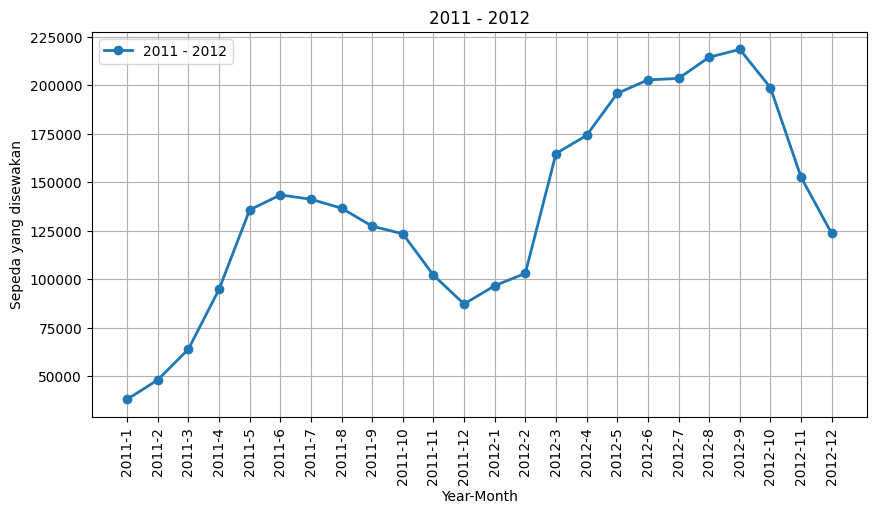

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_progress['yr-mnth'],
    monthly_progress['cnt'],
    marker='o',
    linewidth=2,
    label='2011 - 2012'
)
plt.title('2011 - 2012')
plt.xlabel('Year-Month')
plt.ylabel('Sepeda yang disewakan')
plt.grid(True)
plt.legend()
plt.xticks(rotation=90)
plt.show()

**Insight:**

- Pertumbuhan Signifikan: Secara keseluruhan, jumlah sepeda yang disewakan mengalami peningkatan yang jauh lebih tinggi pada tahun 2012 dibandingkan dengan tahun 2011.

- Pola Musiman: Terdapat pola musiman yang jelas di mana penyewaan meningkat tajam di pertengahan tahun (sekitar bulan Mei hingga September) dan menurun drastis menjelang akhir tahun (November hingga Desember).

- Titik Tertinggi (Peak): Puncak penyewaan tertinggi terjadi pada bulan September 2012, dengan jumlah sepeda yang disewakan mencapai lebih dari 210.000 unit.

- Titik Terendah: Jumlah penyewaan terendah berada pada awal tahun 2011 (Januari), yang kemudian terus tumbuh secara bertahap setiap tahunnya.

### Pertanyaan 2:

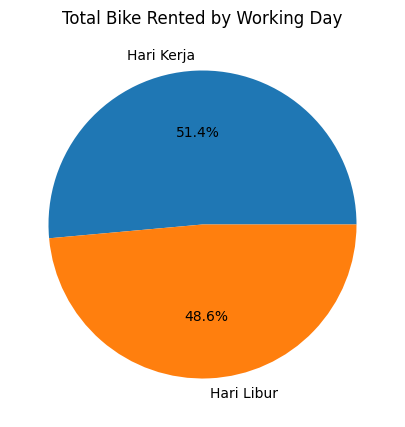

In [35]:
plt.figure(figsize=(10, 5))
plt.pie(
    x=workingday_trend['cnt']['mean'],
    labels=['Hari Kerja', 'Hari Libur'],
    autopct='%1.1f%%',
)
plt.title('Total Bike Rented by Working Day')
plt.grid(True)
plt.show()

**Insight:**
Peminjaman Sepeda pada saat hari kerja lebih banyak dibandingkan saat hari libur

### Pertanyaan 3:

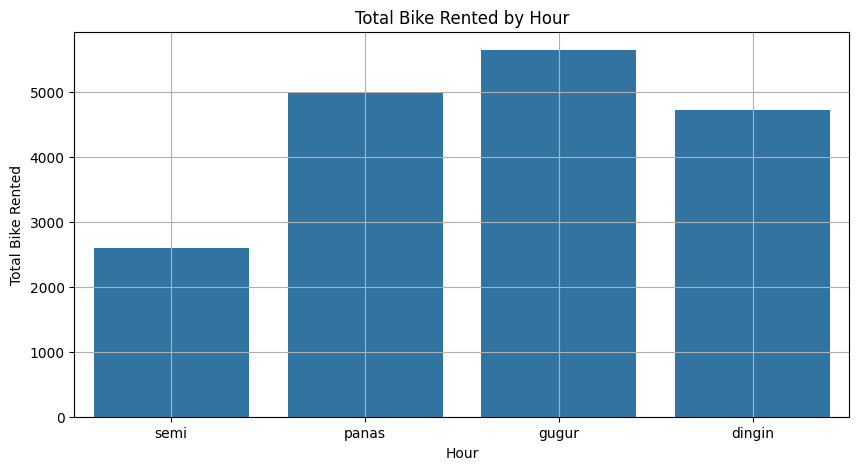

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x='season',
    y=('cnt', 'mean'),
    data=seasonal_trend
)
plt.title('Total Bike Rented by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Bike Rented')
plt.grid(True)
plt.show()

**Insight:**
- Musim Puncak (Peak Season): Musim gugur merupakan periode dengan jumlah peminjaman sepeda tertinggi, mencapai lebih dari 5.000 peminjaman. Hal ini menunjukkan bahwa kondisi cuaca pada musim gugur kemungkinan paling ideal bagi pengguna untuk bersepeda.

- Musim Ramah Bersepeda: Musim panas menempati urutan kedua dengan jumlah peminjaman yang mencapai angka 5.000. Meskipun cuaca panas, minat pengguna tetap tinggi.

- Penurunan di Musim Dingin: Terjadi sedikit penurunan pada musim dingin dibandingkan musim panas dan gugur, namun jumlahnya tetap signifikan di angka mendekati 5.000 peminjaman.

- Aktivitas Terendah: Musim semi menunjukkan jumlah peminjaman paling sedikit dibandingkan musim lainnya, dengan angka yang berada di kisaran 2.500 hingga 3.000 peminjaman. Ini menunjukkan adanya penurunan aktivitas bersepeda yang cukup drastis di awal tahun atau musim semi.

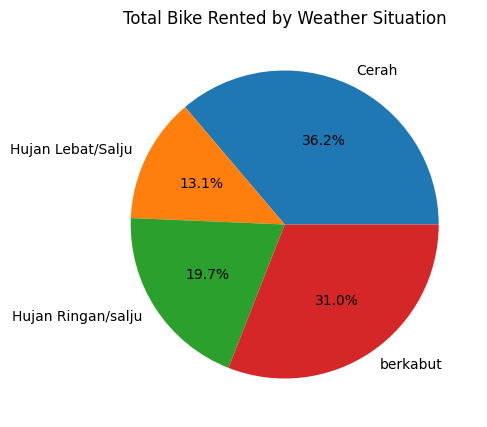

In [37]:
plt.figure(figsize=(10, 5))
plt.pie(
    x=trend_by_weather['cnt']['mean'],
    labels=trend_by_weather.index,
    autopct='%1.1f%%',
)
plt.title('Total Bike Rented by Weather Situation')
plt.grid(True)
plt.show()

**Insight:**
- Dominasi Cuaca Cerah: Tingkat peminjaman sepeda paling tinggi terjadi saat cuaca Cerah, yaitu sebesar 36,2%.

- Kondisi Berkabut: Cuaca berkabut menempati posisi kedua dengan kontribusi sebesar 31,0% terhadap total peminjaman.

- Pengaruh Hujan Ringan: Saat terjadi Hujan Ringan/salju, persentase peminjaman menurun menjadi 19,7%.

- Aktivitas Terendah: Kondisi Hujan Lebat/Salju memiliki persentase peminjaman paling kecil, yakni hanya 13,1%.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Secara keseluruhan, peminjaman sepeda mengalami pertumbuhan yang signifikan pada tahun 2012 dibandingkan tahun 2011 dengan tetap mengikuti pola fluktuasi musiman yang serupa.
- **Conclusion pertanyaan 2:** Jumlah peminjaman sepeda pada hari kerja (51,4%) sedikit lebih tinggi dibandingkan pada hari libur (48,6%), namun perbedaan keduanya tidak terlalu signifikan sehingga menunjukkan minat penggunaan sepeda yang hampir seimbang baik untuk kebutuhan transportasi harian maupun rekreasi.
- **Conclusion pertanyaan 3:** Peminjaman sepeda mencapai angka tertinggi pada musim gugur dan saat kondisi cuaca cerah (36,2%), sementara aktivitas terendah terjadi pada musim semi dan saat terjadi hujan lebat atau salju (13,1%).

**Rekomendasi Action Item:**
- Preventive Maintenance di Musim Semi: Karena musim semi memiliki tren peminjaman terendah, manfaatkan waktu ini untuk melakukan perawatan besar-besaran pada seluruh armada sepeda agar siap menghadapi lonjakan di musim panas dan gugur.

- Alokasi Armada Maksimal di Kuartal 3: Siapkan jumlah sepeda maksimal pada bulan Agustus hingga September, karena data menunjukkan ini adalah titik puncak peminjaman tertinggi dalam setahun.

- Mitigasi Cuaca Buruk: Mengingat penurunan drastis saat hujan lebat (hanya 13,1% peminjaman), sediakan fasilitas pendukung seperti area parkir sepeda yang beratap atau penyediaan jas hujan di stasiun peminjaman untuk menjaga kenyamanan pengguna.

- Ekspansi di Tahun Mendatang: Melihat tren pertumbuhan yang sangat pesat dari 2011 ke 2012, perusahaan harus mulai merencanakan penambahan stasiun peminjaman baru atau peningkatan kapasitas di stasiun yang sudah ada untuk mengantisipasi pertumbuhan berkelanjutan.

- Optimasi Jalur "Working Day": Mengingat penggunaan di hari kerja cukup tinggi (51,4%), pastikan stasiun sepeda terletak strategis di dekat area perkantoran, stasiun kereta, atau terminal bus untuk mendukung kebutuhan commuting.

In [38]:
main_df.to_csv("main_data.csv", index=False)